In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from my_nn import activations, loss, metrics, nn
from my_nn.data.sample_data import generate_data, plot_data

#### This notebook is to see the effect of adding batch normalization layers on the multiclass classification example

In [2]:
# first get the data
data, targets = generate_data(seed=42)

In [3]:
# set up X, y for training
# use numpy arrays here for now so train test split works properly
X = np.array(data[["x1","x2"]])
y = np.array(data["multiclass"])
data_used = data[["x1","x2","multiclass"]].copy()

In [4]:
# do a train_test split
X_train, X_test, y_train, y_test = nn.train_test_split(X, y, test_size = 0.2, random_state=42)

Here we create 2 different networks , one with no batch normalization layers, and one with batch normalization between dense layers

In [5]:
model_sgd = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 3, activation="softmax")
)

model_sgd_bn = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.BatchNorm(30),
    nn.Dense(30, 30, activation="relu"),
    nn.BatchNorm(30),
    nn.Dense(30, 30, activation="relu"),
    nn.BatchNorm(30),
    nn.Dense(30, 3, activation="softmax")
)

In [6]:
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="categorical_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 0.8269 , accuracy 0.6288 -  Validation Loss: 0.7427, Validation accuracy 0.6400
Epoch 2 complete. Average Loss: 0.6994 , accuracy 0.6897 -  Validation Loss: 0.6529, Validation accuracy 0.6919
Epoch 3 complete. Average Loss: 0.6201 , accuracy 0.7238 -  Validation Loss: 0.5855, Validation accuracy 0.7369
Epoch 4 complete. Average Loss: 0.5596 , accuracy 0.8298 -  Validation Loss: 0.5332, Validation accuracy 0.8337
Epoch 5 complete. Average Loss: 0.5115 , accuracy 0.8472 -  Validation Loss: 0.4899, Validation accuracy 0.8531
Epoch 6 complete. Average Loss: 0.4725 , accuracy 0.8509 -  Validation Loss: 0.4535, Validation accuracy 0.8606
Epoch 7 complete. Average Loss: 0.4402 , accuracy 0.8602 -  Validation Loss: 0.4241, Validation accuracy 0.8700
Epoch 8 complete. Average Loss: 0.4133 , accuracy 0.8636 -  Validation Loss: 0.3993, Validation accuracy 0.8756
Epoch 9 complete. Average Loss: 0.3906 , accuracy 0.8691 -  Validation Loss: 0.3784, Validation accuracy

In [7]:
history_sgd_bn = model_sgd_bn.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="categorical_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 1.0757 , accuracy 0.7241 -  Validation Loss: 1.0413, Validation accuracy 0.7281
Epoch 2 complete. Average Loss: 1.0131 , accuracy 0.8161 -  Validation Loss: 0.9775, Validation accuracy 0.8131
Epoch 3 complete. Average Loss: 0.9510 , accuracy 0.8548 -  Validation Loss: 0.9101, Validation accuracy 0.8462
Epoch 4 complete. Average Loss: 0.8889 , accuracy 0.8533 -  Validation Loss: 0.8510, Validation accuracy 0.8369
Epoch 5 complete. Average Loss: 0.8191 , accuracy 0.9095 -  Validation Loss: 0.7714, Validation accuracy 0.9012
Epoch 6 complete. Average Loss: 0.7476 , accuracy 0.9234 -  Validation Loss: 0.6963, Validation accuracy 0.9156
Epoch 7 complete. Average Loss: 0.6761 , accuracy 0.9345 -  Validation Loss: 0.6283, Validation accuracy 0.9281
Epoch 8 complete. Average Loss: 0.6061 , accuracy 0.9456 -  Validation Loss: 0.5452, Validation accuracy 0.9394
Epoch 9 complete. Average Loss: 0.5337 , accuracy 0.9505 -  Validation Loss: 0.4854, Validation accuracy

#### Look at loss/val_loss and accuracy/val_accuracy for each

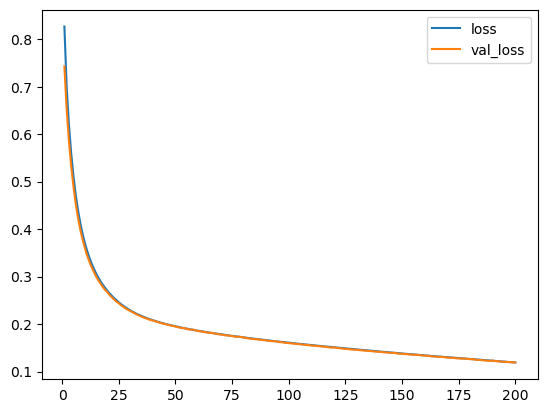

In [8]:
nn.plot_history(history_sgd, "loss", "val_loss")

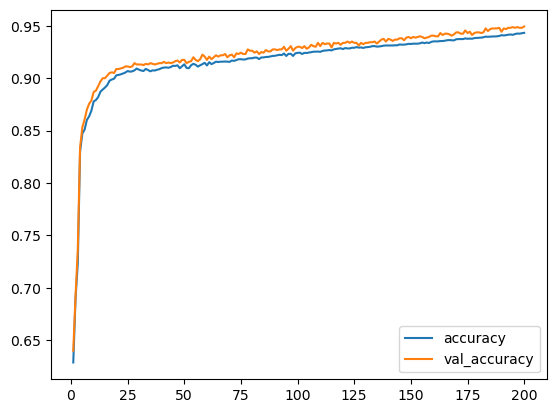

In [9]:
nn.plot_history(history_sgd, "accuracy", "val_accuracy")

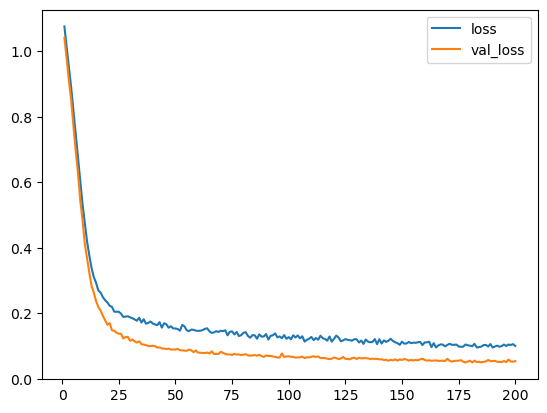

In [10]:
nn.plot_history(history_sgd_bn, "loss", "val_loss")

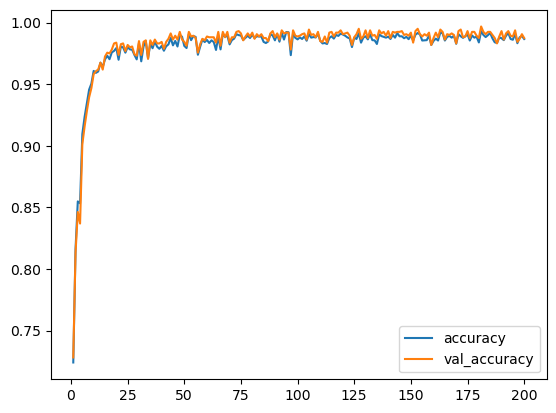

In [11]:
nn.plot_history(history_sgd_bn, "accuracy", "val_accuracy")

##### Let's see how they do on unseen data points

In [14]:
y_pred_sgd = model_sgd.predict(X_test)
y_pred_sgd_bn = model_sgd_bn.predict(X_test)

In [29]:
y_pred_sgd_labels = np.argmax(y_pred_sgd, axis=1)
y_pred_sgd_bn_labels = np.argmax(y_pred_sgd_bn, axis=1)

In [30]:
acc_sgd = metrics.accuracy(y_test, y_pred_sgd_labels)
acc_sgd_bn = metrics.accuracy(y_test,y_pred_sgd_bn_labels)

In [31]:
print(f"Accuracy on X_test with SGD, no batch norm: {acc_sgd :.5f}")
print(f"Accuracy on X_test with SGD, with batch norm: {acc_sgd_bn:.5f}")

Accuracy on X_test with SGD, no batch norm: 0.95150
Accuracy on X_test with SGD, with batch norm: 0.98750


#### We visualize loss/val_loss for both models on the same graph

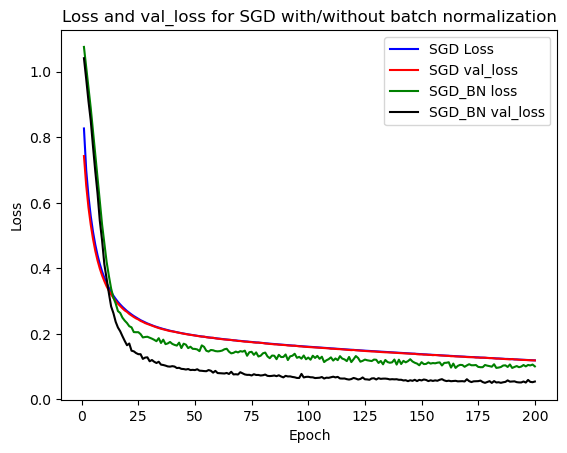

In [21]:
#comparing loss/val_loss with SGD, with/without BN
x_l, y_l = zip(*history_sgd["loss"])
x_vl, y_vl = zip(*history_sgd["val_loss"])
x_bl, y_bl = zip(*history_sgd_bn["loss"])
x_vbl, y_vbl = zip(*history_sgd_bn["val_loss"])

plt.plot(x_l, y_l, color="blue")
plt.plot(x_vl, y_vl, color = "red")
plt.plot(x_bl, y_bl, color = "green")
plt.plot(x_vbl, y_vbl, color = "black")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss and val_loss for SGD with/without batch normalization")
plt.legend(["SGD Loss", "SGD val_loss", "SGD_BN loss", "SGD_BN val_loss"])
plt.show()

#### Now we do the same sort of experiment with Adam optimization

In [23]:
model_adam = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 3, activation="softmax")
)

model_adam_bn = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.BatchNorm(30),
    nn.Dense(30, 30, activation="relu"),
    nn.BatchNorm(30),
    nn.Dense(30, 30, activation="relu"),
    nn.BatchNorm(30),
    nn.Dense(30, 3, activation="softmax")
)

In [24]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="categorical_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 0.1705 , accuracy 0.9675 -  Validation Loss: 0.0747, Validation accuracy 0.9694
Epoch 2 complete. Average Loss: 0.0942 , accuracy 0.9742 -  Validation Loss: 0.0637, Validation accuracy 0.9806
Epoch 3 complete. Average Loss: 0.0785 , accuracy 0.9803 -  Validation Loss: 0.0661, Validation accuracy 0.9762
Epoch 4 complete. Average Loss: 0.0685 , accuracy 0.9697 -  Validation Loss: 0.0730, Validation accuracy 0.9712
Epoch 5 complete. Average Loss: 0.0620 , accuracy 0.9761 -  Validation Loss: 0.0546, Validation accuracy 0.9769
Epoch 6 complete. Average Loss: 0.0476 , accuracy 0.9692 -  Validation Loss: 0.0594, Validation accuracy 0.9744
Epoch 7 complete. Average Loss: 0.0534 , accuracy 0.9820 -  Validation Loss: 0.0404, Validation accuracy 0.9825
Epoch 8 complete. Average Loss: 0.0603 , accuracy 0.9834 -  Validation Loss: 0.0383, Validation accuracy 0.9850
Epoch 9 complete. Average Loss: 0.0512 , accuracy 0.9819 -  Validation Loss: 0.0383, Validation accuracy

In [25]:
history_adam_bn = model_adam_bn.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="categorical_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 0.2249 , accuracy 0.9425 -  Validation Loss: 0.1394, Validation accuracy 0.9469
Epoch 2 complete. Average Loss: 0.1540 , accuracy 0.9452 -  Validation Loss: 0.1639, Validation accuracy 0.9425
Epoch 3 complete. Average Loss: 0.1222 , accuracy 0.9755 -  Validation Loss: 0.0634, Validation accuracy 0.9719
Epoch 4 complete. Average Loss: 0.1149 , accuracy 0.9658 -  Validation Loss: 0.0903, Validation accuracy 0.9569
Epoch 5 complete. Average Loss: 0.0956 , accuracy 0.9719 -  Validation Loss: 0.0663, Validation accuracy 0.9675
Epoch 6 complete. Average Loss: 0.0996 , accuracy 0.9606 -  Validation Loss: 0.1389, Validation accuracy 0.9500
Epoch 7 complete. Average Loss: 0.0889 , accuracy 0.9553 -  Validation Loss: 0.1070, Validation accuracy 0.9531
Epoch 8 complete. Average Loss: 0.0855 , accuracy 0.9641 -  Validation Loss: 0.1072, Validation accuracy 0.9575
Epoch 9 complete. Average Loss: 0.0952 , accuracy 0.9817 -  Validation Loss: 0.0513, Validation accuracy

#### We skip the individual model history graphs but look at all the losses on one graph

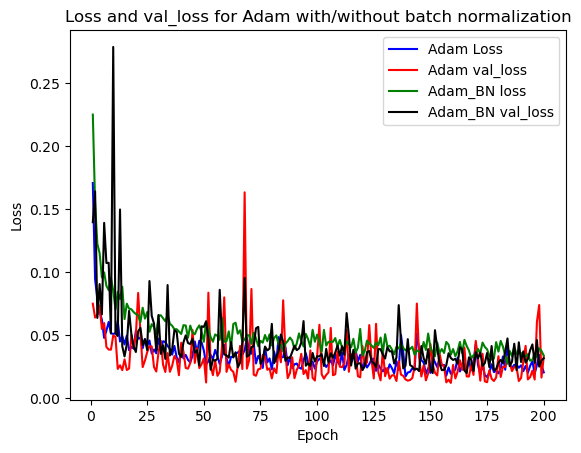

In [27]:
#comparing loss/val_loss with adam, with/without BN
x_l, y_l = zip(*history_adam["loss"])
x_vl, y_vl = zip(*history_adam["val_loss"])
x_bl, y_bl = zip(*history_adam_bn["loss"])
x_vbl, y_vbl = zip(*history_adam_bn["val_loss"])

plt.plot(x_l, y_l, color="blue")
plt.plot(x_vl, y_vl, color = "red")
plt.plot(x_bl, y_bl, color = "green")
plt.plot(x_vbl, y_vbl, color = "black")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss and val_loss for Adam with/without batch normalization")
plt.legend(["Adam Loss", "Adam val_loss", "Adam_BN loss", "Adam_BN val_loss"])
plt.show()

#### Finally we test on unseen data points for both

In [28]:
y_pred_adam = model_adam.predict(X_test)
y_pred_adam_bn = model_adam_bn.predict(X_test)

In [32]:
y_pred_adam_labels = np.argmax(y_pred_adam, axis=1)
y_pred_adam_bn_labels = np.argmax(y_pred_adam_bn, axis=1)

In [33]:
acc_adam = metrics.accuracy(y_test, y_pred_adam_labels)
acc_adam_bn = metrics.accuracy(y_test, y_pred_adam_bn_labels)

In [34]:
print(f"Accuracy on X_test with Adam, no batch norm: {acc_adam :.5f}")
print(f"Accuracy on X_test with Adam, with batch norm: {acc_adam_bn:.5f}")

Accuracy on X_test with Adam, no batch norm: 0.98700
Accuracy on X_test with Adam, with batch norm: 0.99150
